In [2]:
import sys
import os
sys.path.append(os.path.abspath('../'))

from utlis.sync_utlis.sync_df_utlis import process_sync
from utlis.exe_engine_utlis.comb_all_exe import mir_generate_param_z

test_path = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3"

base_path = os.path.dirname(test_path.rstrip("/"))   # .../2025_09_19
rec       = os.path.basename(test_path.rstrip("/"))  # 1eNpHR_10base10opto_12_17
calib     = os.path.join(base_path, "after_mouse_validate")
out = f"{os.path.basename(base_path)}_{rec}_{os.path.basename(calib)}_label3d_dannce.mat"

# mir_generate_param_z(base_path, calib, rec, out)


Saved brightness plot to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3/videos/6cam_sync.png


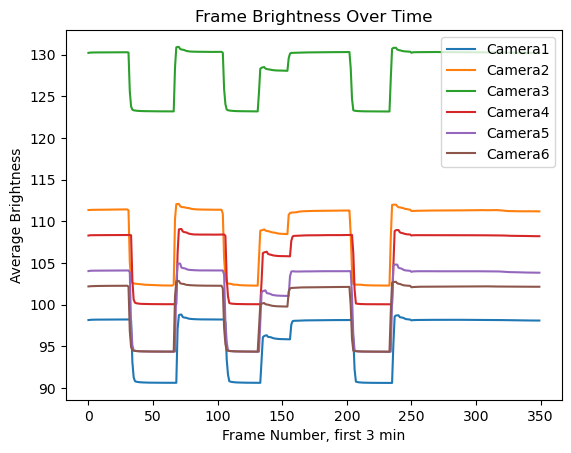

Detected intensity drop frames in /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3: {'Camera1': [34, 107, 205, 206], 'Camera2': [32, 33, 105, 106, 203, 204], 'Camera3': [32, 105, 204], 'Camera4': [34, 35, 107, 108, 205, 206], 'Camera5': [33, 34, 106, 107, 204, 205], 'Camera6': [32, 105, 203, 204]}
Processed drop frames: {'Camera1': 34, 'Camera2': 33, 'Camera3': 32, 'Camera4': 35, 'Camera5': 34, 'Camera6': 32}
32
alined data saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3/df_synced_2025_10_17_record_mouse_validate_3_after_mouse_validate_label3d_dannce.mat
Alignment successful for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3 with /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3/2025_10_17_record_mouse_validate_3_after_mouse_validate_label3d_dannce.mat 
Moved prior calibrat

True

In [7]:
process_sync(test_path, threshold=2, max_frames=600, min_frame=250) #, min_frame=150 here the min frame will actually shift it which is not ideal, but it works, all we need is alignment so whatever...


In [8]:
# single rerun com
import os

dry_run = False 
txt_file = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3/prev_calib/com_run.txt"
slurm_launch_file = '/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py'

# Function to create the full expdir path and print the command for dry-run
def run_command(expdir_path, partition, dry_run=True):

    # command = f"python {slurm_launch_file} --expdir {expdir_path} --predict_com"
    command = f"conda run -n sdannce python {slurm_launch_file} --expdir {expdir_path} --predict_com --allow_overwrite --partition {partition}" # --allow_overwrite remove allow_overwrite by default.

    if dry_run:
        print(f"[DRY-RUN] Command: {command}")
    else:
        print(f"Executing command: {command}")
        os.system(command)
# Read the experiment directories from the .txt file and execute the command for each
with open(txt_file, 'r') as f:
    for line in f:
        expdir_path = line.strip()
        if not expdir_path:
            continue  # Skip empty lines
        # expdir_path = os.path.join(base_path, relative_path)
        run_command(expdir_path, 'scavenger-gpu',dry_run) #tdunn scavenger-gpu

Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3 --predict_com --allow_overwrite --partition scavenger-gpu
Specified a single expdir; running predictions ...
Running command:  cd /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3
dannce predict com /hpc/group/tdunn/tqxli/sdannce_scripts/configs/com_mouse_config.yaml --com-predict-weights=/hpc/group/tdunn/tqxli/sdannce_scripts/weights/COM/checkpoint-epoch20.pth --com-predict-dir=COM/predict00 --max-num-samples 100000 --batch-size=1
Copying default io file /hpc/group/tdunn/tqxli/sdannce_scripts/io_files/io.yaml to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3
Slurm out: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mou

plotting com_traga for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3


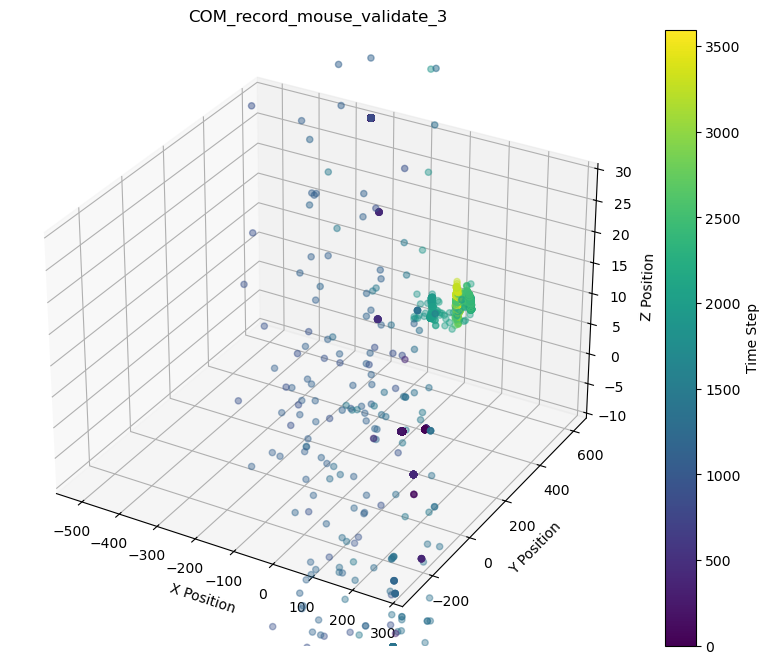

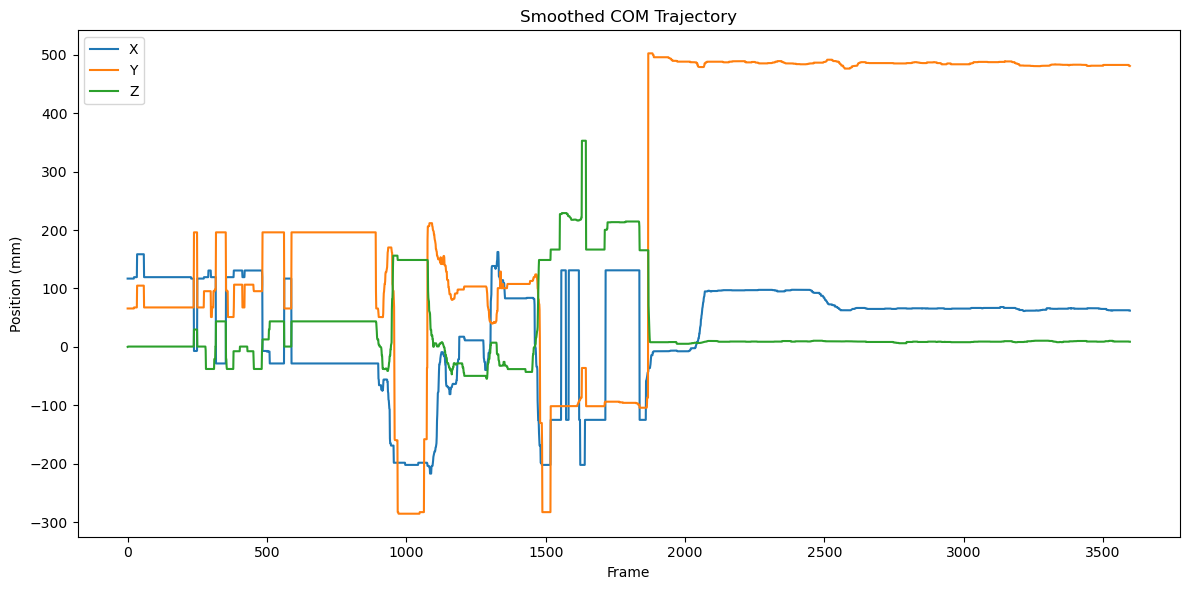

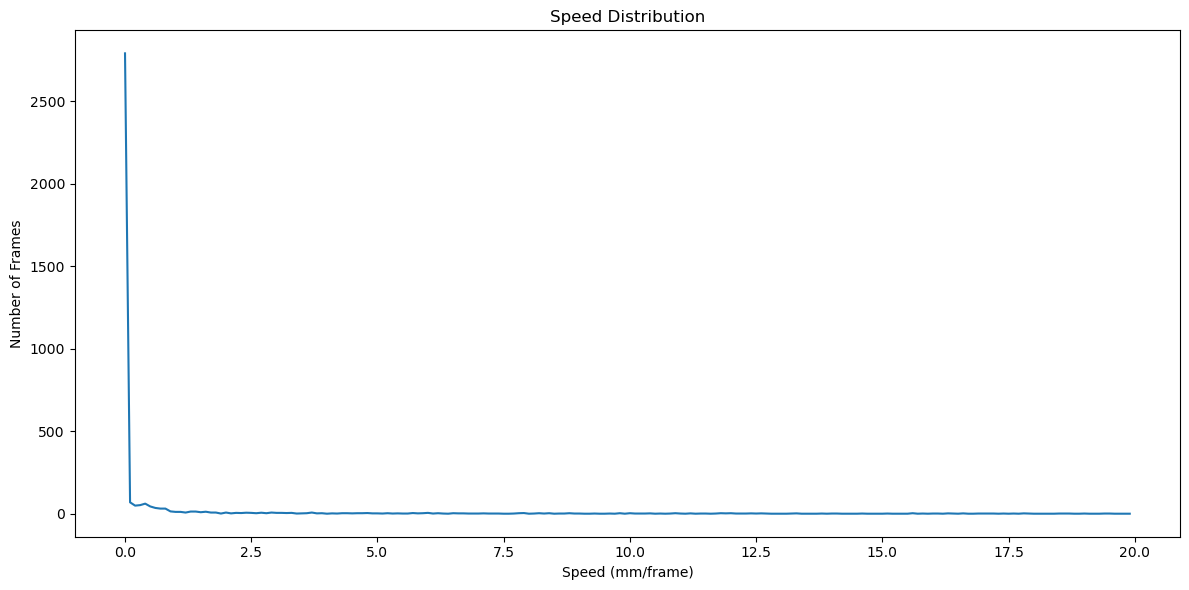

Analysis complete. Plots saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3/COM/predict00/vis


In [9]:
#single com vis

import sys
import os
sys.path.append(os.path.abspath('../'))
from utlis.vis_valid_utlis.com_trag_updated import plot_com_all

rel_paths_to_skip = set()
with open(txt_file, 'r') as f:
    for line in f:
        rel_path = line.strip()
        if rel_path:
            rel_paths_to_skip.add(rel_path)
            
for b in rel_paths_to_skip:
    plot_com_all(b) # , perform_jump_indices=True, perform_video_generation=True#com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False

In [4]:
# single rerun dannce

import os

dry_run = False 
txt_file = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3/prev_calib/com_run.txt"

slurm_launch_file = "/hpc/group/tdunn/lq53/251017_new_dannce_files/slurm_launch_predict.py"
# '/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py'


# Function to create the full expdir path and print the command for dry-run
def run_command(expdir_path, partition, dry_run=True):

    command = f"conda run -n sdannce python {slurm_launch_file} --expdir {expdir_path} --predict_dannce --allow_overwrite --partition {partition}" # --allow_overwrite remove allow_overwrite by default.
    # predict_dannce --dannce predict sdannce
    if dry_run:
        print(f"[DRY-RUN] Command: {command}")
    else:
        print(f"Executing command: {command}")
        os.system(command)
# Read the experiment directories from the .txt file and execute the command for each
with open(txt_file, 'r') as f:
    for line in f:
        expdir_path = line.strip()
        if not expdir_path:
            continue  # Skip empty lines
        # expdir_path = os.path.join(base_path, relative_path)
        run_command(expdir_path, 'scavenger-gpu',dry_run) # cavenger-gpu #tdunn

Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/251017_new_dannce_files/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3 --predict_dannce --allow_overwrite --partition scavenger-gpu
Specified a single expdir; running predictions ...
Running command:  cd /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3
dannce predict dannce /hpc/group/tdunn/tqxli/sdannce_scripts/configs/dannce_mouse_config_vsize240.yaml --dannce-predict-model=/hpc/group/tdunn/tqxli/sdannce_scripts/weights/DANNCE/train04_20241111_ft_mouse_demo/checkpoint-epoch60.pth --dannce-predict-dir=DANNCE/predict00 --com-file=COM/predict00/com3d0.mat --max-num-samples 100000 --batch-size=1
Slurm out: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3/slurm/predict_dannce_record_mouse_validate_3.out
Submitted batch job 38429966



Plot saved as '/hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3/DANNCE/predict00/vis/2025_10_17_record_mouse_validate_3.jpg'.


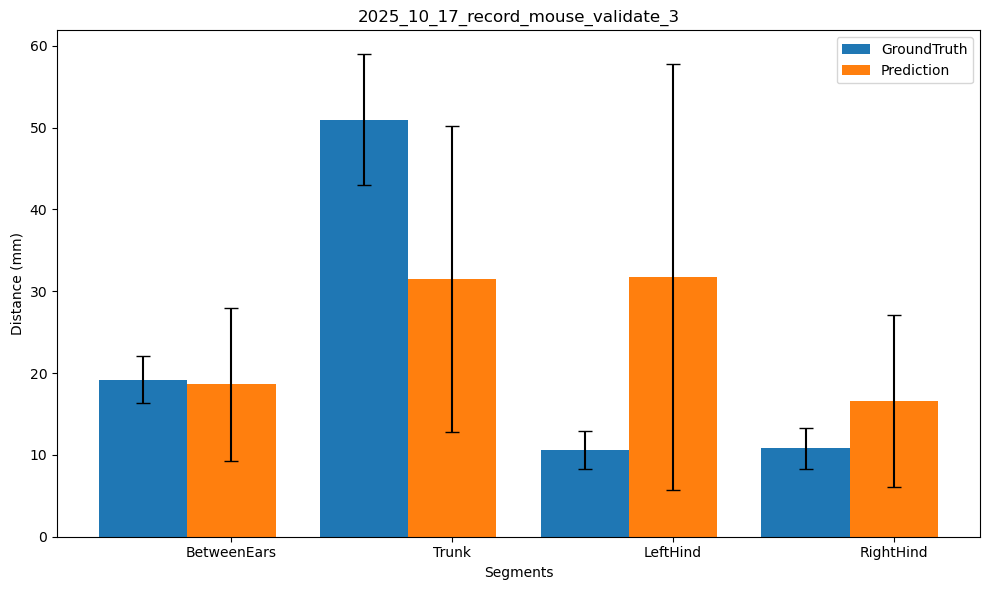

In [2]:
#single dannce vis

import sys
import os
sys.path.append(os.path.abspath('../'))
from useful_files.sophie_check_dannce_mir_modif import dannce_valid
txt_file = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/yankun_calibration_free/2025_10_17/record_mouse_validate_3/prev_calib/com_run.txt"

rel_paths_to_skip = set()
with open(txt_file, 'r') as f:
    for line in f:
        rel_path = line.strip()
        if rel_path:
            rel_paths_to_skip.add(rel_path)
            
for b in rel_paths_to_skip:
    dannce_valid(b) # , perform_jump_indices=True, perform_video_generation=True#com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False